# Рубежный контроль №1
**Выполнила:** Каверина Софья, группа ИУ5-66Б  
**Вариант:** 8  
**Задача:** 1 Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель. Дополнительно для группы ИУ5-66Б - для набора данных построить "парные диаграммы". 
**Набор данных:** 8 (Boston Housing Dataset)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "/home/cherry4xo/Documents/goKittyGo/HousingData.csv"
data = pd.read_csv(url)

if 'crim' in data.columns:
    data = data.drop(columns=['crim'])

print("Размерность исходного датасета:", data.shape)
data.head()

Размерность исходного датасета: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [6]:
print("Количество пропусков до обработки:")
print(data.isnull().sum()[data.isnull().sum() > 0])

data_cleaned = data.dropna(axis=0)
print("\nРазмерность после удаления строк с пропусками:", data_cleaned.shape)

Количество пропусков до обработки:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64

Размерность после удаления строк с пропусками: (394, 14)


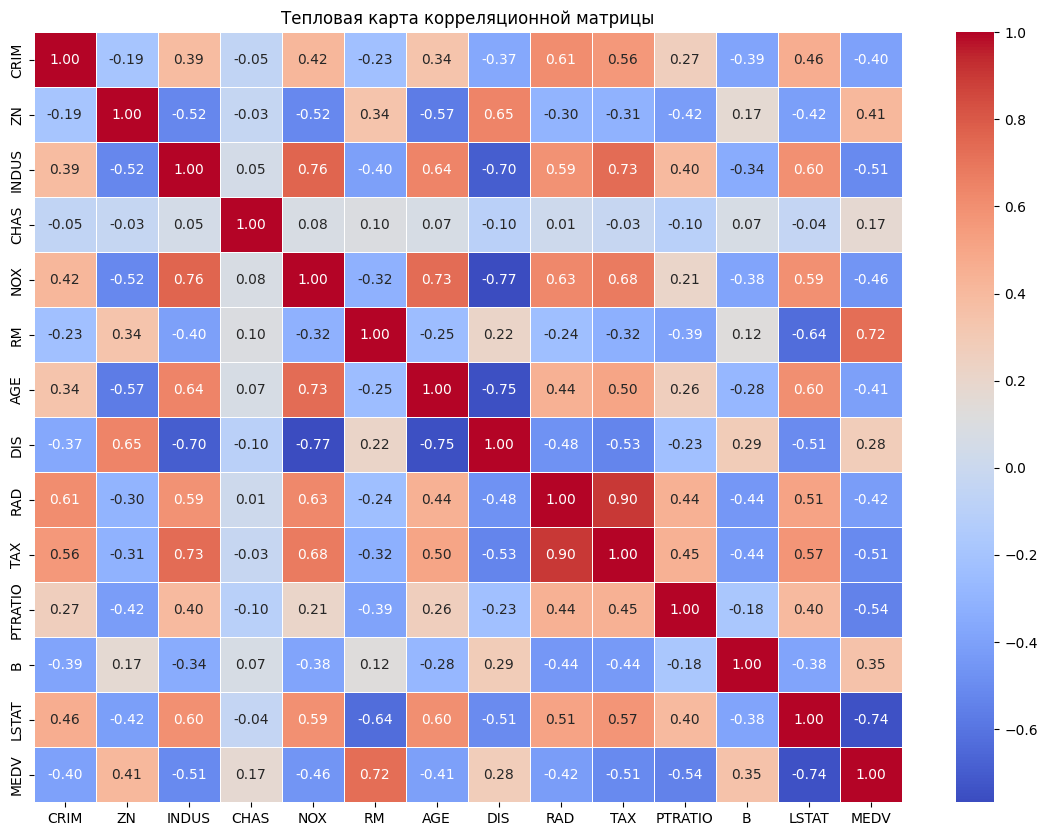

In [7]:
corr_matrix = data_cleaned.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Тепловая карта корреляционной матрицы')
plt.show()

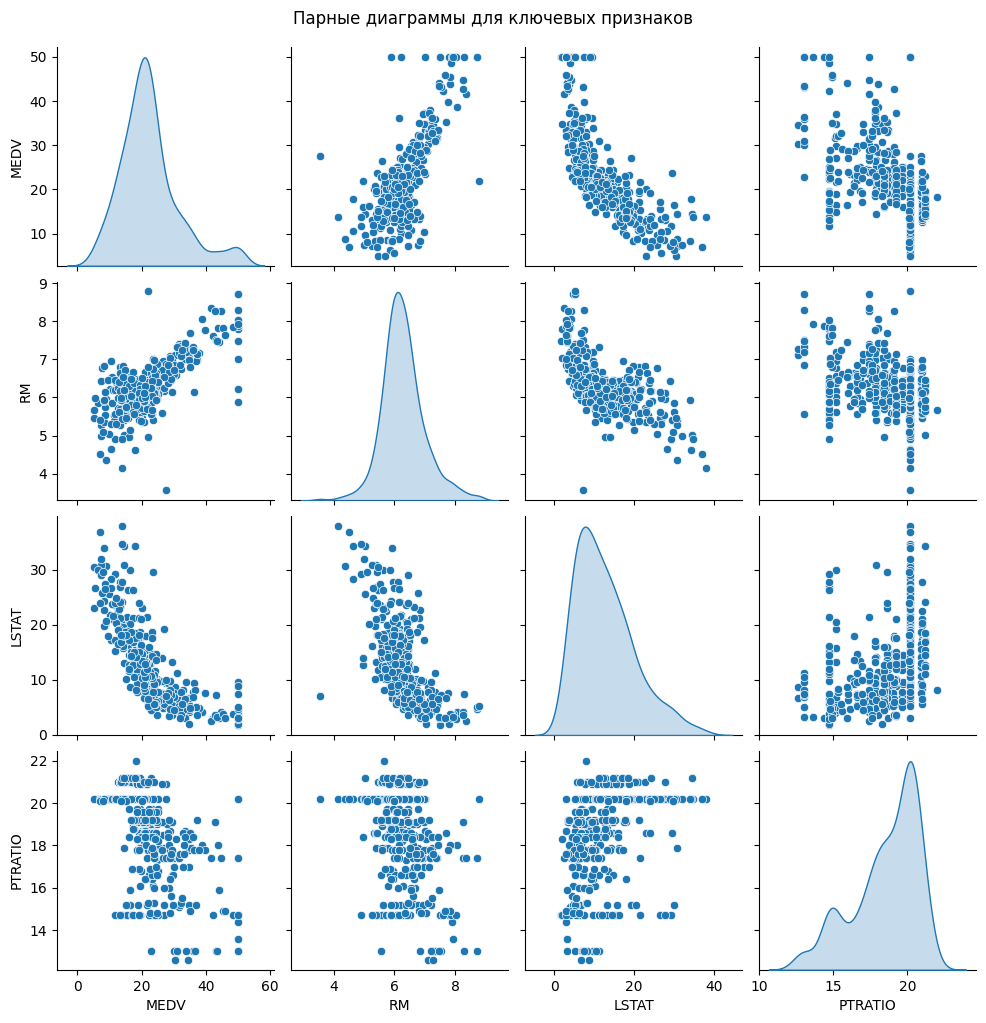

In [8]:
features_for_pairplot =['MEDV', 'RM', 'LSTAT', 'PTRATIO']
valid_features =[f for f in features_for_pairplot if f in data_cleaned.columns]
if len(valid_features) > 1:
    sns.pairplot(data_cleaned[valid_features], diag_kind='kde')
    plt.suptitle('Парные диаграммы для ключевых признаков', y=1.02)
    plt.show()
else:
    print("Не удалось построить парные диаграммы: нужные колонки были удалены из-за пропусков.")

### Выводы по результатам разведочного анализа:

**1. Обработка пропусков:**
В исходном наборе данных присутствовали пропуски. В соответствии с заданием, они были обработаны методом удаления строк (`dropna(axis=0)`). Потеря данных составила допустимый процент, оставшегося объема достаточно для дальнейшего анализа.

**2. Вклад признаков в модель (анализ корреляций):**
Целевой переменной в данном наборе является `MEDV` (медианная стоимость жилья). На основе корреляционной матрицы выявлены признаки, которые внесут наибольший вклад в будущую модель машинного обучения:
* **RM** (среднее количество комнат): имеет сильную **положительную** корреляцию с MEDV ($r \approx 0.70$). Чем больше комнат, тем дороже недвижимость.
* **LSTAT** (% населения с низким статусом): имеет сильную **отрицательную** корреляцию с MEDV ($r \approx -0.74$). 
* **PTRATIO** (соотношение учеников и учителей): также имеет значимую **отрицательную** корреляцию с целевой переменной ($r \approx -0.51$).

Данные признаки имеют явные (линейные и нелинейные) зависимости с целевой переменной, что визуально подтверждается построенными парными диаграммами.

**3. Мультиколлинеарность:**
В данных наблюдается сильная корреляция между некоторыми независимыми признаками. Например, между `TAX` (налог) и `RAD` (доступность магистралей) корреляция составляет $\approx 0.91$. При построении линейных моделей один из этих признаков рекомендуется исключить для повышения устойчивости модели и предотвращения переобучения.

**4. Возможность построения моделей машинного обучения:**
Данный набор признаков отлично подходит для решения задачи **регрессии**. Данные содержат сильные предикторы (RM, LSTAT), зависимости хорошо прослеживаются. После дополнительного масштабирования признаков можно применять как линейные модели (Linear Regression), так и более сложные алгоритмы (например, Random Forest или Gradient Boosting).